<a href="https://colab.research.google.com/github/Sherry66410/ML-PROJECT/blob/main/Day6_internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#UNSUPERVISED LEARNING
#training of unlabeled data(transforming to labelled)
#common techniques: clustering ,dimensionality reduction(feautures providing same meaning is reduced into one), association rule learning
#applications of UL: customer segmentation, fraud detection, image&video analysis, recommendation system

#K-means clustering(clustering technique):
#here k represents number of clusters.
#wcss(within cluster sum of squares)(to check out the required num of clusters)
#through wcss optimal num of k is where the cut(elobw bend) occurs in elbow method graph


#Silhouette Score(metric of kmeans):
#(how close am i to other pnts in my cluster(cohesion), how far am i from pnts in the nearest other cluster(seperation))
#values ranges from -1 to 1:
                           #1=data pnt is well clustered
                           # 0=very close to decision bndry b/w two nghboring cluster,

                           #-1=data pnt might have been assigned to wrong cluster
  #consider both the metric while using k means clustering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.shape

(200, 5)

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [ ]:
df.nunique()


,0
CustomerID,200
Gender,2
Age,51
Annual Income (k$),64
Spending Score (1-100),84


In [ ]:
df.drop(['CustomerID','Gender'],axis=1,inplace=True)



<Axes: >

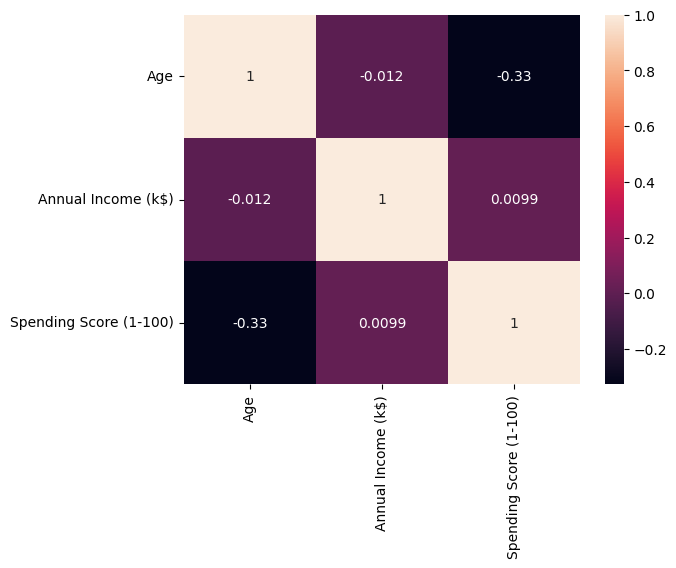

In [ ]:
sns.heatmap(df.corr(),annot=True)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

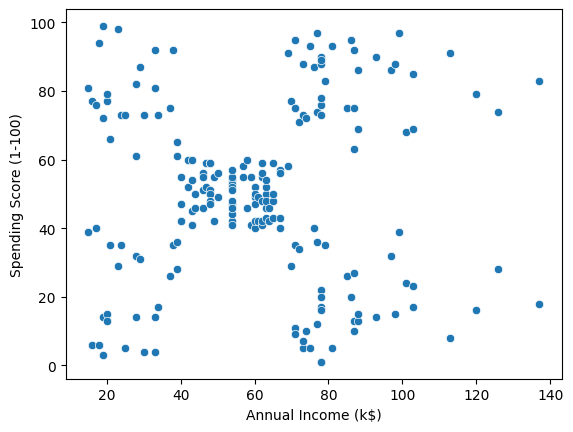

In [ ]:
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)')


In [ ]:
#applying scaling because age, income and spending score are diff measures
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [ ]:
X_scaled=scaler.fit_transform(df.drop(['Age'],axis=1))
X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
wcss=[]
sil_scores=[]
for k in range(2,11):
  kmeans=KMeans(n_clusters=k,random_state=42, init='k-means++',max_iter=300,n_init=10)
  kmeans.fit_predict(X_scaled)
  labels=kmeans.labels_
  wcss.append(kmeans.inertia_)
  sil_h=silhouette_score(X_scaled,labels)
  sil_scores.append(sil_h)



In [ ]:
wcss

[269.69101219276405,
 157.70400815035939,
 108.92131661364358,
 65.56840815571681,
 55.057348270385965,
 44.86475569922555,
 37.22818767758587,
 32.39226763033118,
 29.981897788243703]

In [ ]:
sil_h

np.float64(0.4431713026508046)

In [ ]:
sil_scores

[np.float64(0.3212707813918878),
 np.float64(0.46658474419000145),
 np.float64(0.4939069237513199),
 np.float64(0.5546571631111091),
 np.float64(0.5398800926790663),
 np.float64(0.5281492781108291),
 np.float64(0.4552147906587443),
 np.float64(0.4570853966942764),
 np.float64(0.4431713026508046)]

In [ ]:
for i,k in enumerate(range(2,11)):
  print(f"for k={k}, wcss={wcss[i]:.2f} and sil_score={sil_scores[i]:.2f}")

for k=2, wcss=269.69 and sil_score=0.32
for k=3, wcss=157.70 and sil_score=0.47
for k=4, wcss=108.92 and sil_score=0.49
for k=5, wcss=65.57 and sil_score=0.55
for k=6, wcss=55.06 and sil_score=0.54
for k=7, wcss=44.86 and sil_score=0.53
for k=8, wcss=37.23 and sil_score=0.46
for k=9, wcss=32.39 and sil_score=0.46
for k=10, wcss=29.98 and sil_score=0.44


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

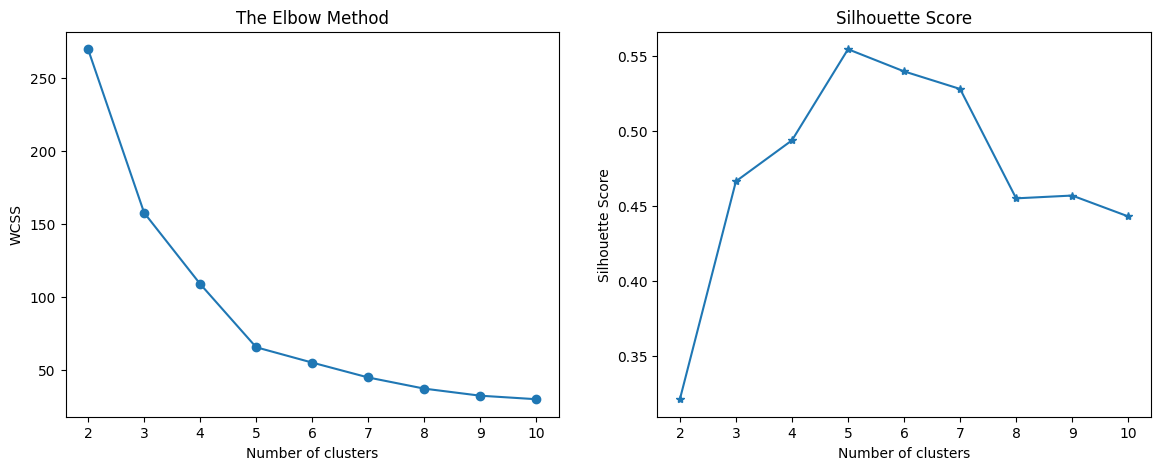

In [ ]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(range(2,11),wcss,marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

plt.subplot(1,2,2)
plt.plot(range(2,11),sil_scores,marker='*')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt

#optimal number of cluster =6

In [ ]:

kmeans=KMeans(n_clusters=5,random_state=42, init='k-means++',max_iter=300,n_init=10)
kmeans.fit_predict(X_scaled)
cluster_labels=kmeans.predict(X_scaled)
cluster_labels

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [ ]:
df['Kmeans_cluster']=cluster_labels
df.head()

,Age,Annual Income (k$),Spending Score (1-100),Kmeans_cluster
0,19,15,39,4
1,21,15,81,2
2,20,16,6,4
3,23,16,77,2
4,31,17,40,4


In [ ]:
df['Kmeans_cluster'].value_counts()

,count
Kmeans_cluster,
0,81
1,39
3,35
4,23
2,22


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

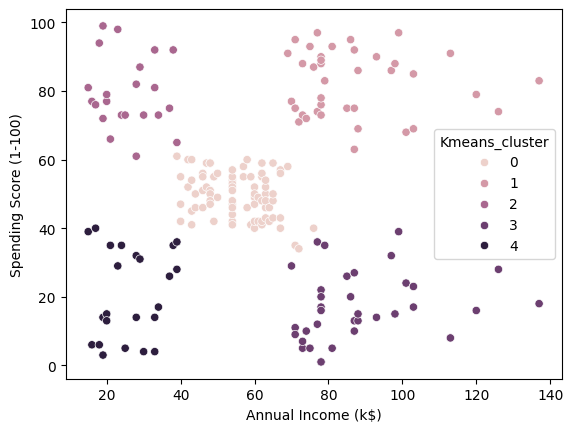

In [ ]:
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)', hue='Kmeans_cluster')

In [ ]:
#checking where new customer falls into
new_customer=np.array([[45,60]])
scaled= scaler.transform(new_customer)
cluster=kmeans.predict(scaled)
cluster

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0], dtype=int32)

In [ ]:
#Agglomerative Hierarchichal Clustering
#chart used is dendogram
from scipy.cluster.hierarchy import dendrogram, linkage



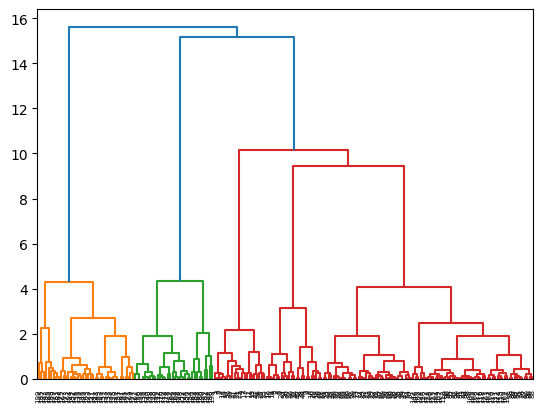

In [ ]:
mergings=linkage(X_scaled,method='ward')
dendrogram(mergings)
plt.show()


In [ ]:
from sklearn.cluster import AgglomerativeClustering

In [ ]:
agg_hc=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
agg_cluster=agg_hc.fit_predict(X_scaled)
agg_cluster

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 2,
       4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

In [ ]:
df['agg_cluster']=agg_cluster
df.head()

,Age,Annual Income (k$),Spending Score (1-100),Kmeans_cluster,agg_cluster
0,19,15,39,4,4
1,21,15,81,2,3
2,20,16,6,4,4
3,23,16,77,2,3
4,31,17,40,4,4


In [ ]:
df['agg_cluster']

,agg_cluster
0,4
1,3
2,4
3,3
4,4
...,...
195,1
196,0
197,1
198,0


In [ ]:
df.Kmeans_cluster.value_counts()

,count
Kmeans_cluster,
0,81
1,39
3,35
4,23
2,22


In [ ]:
df['agg_cluster'].value_counts()

,count
agg_cluster,
2,85
1,39
0,32
4,23
3,21


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

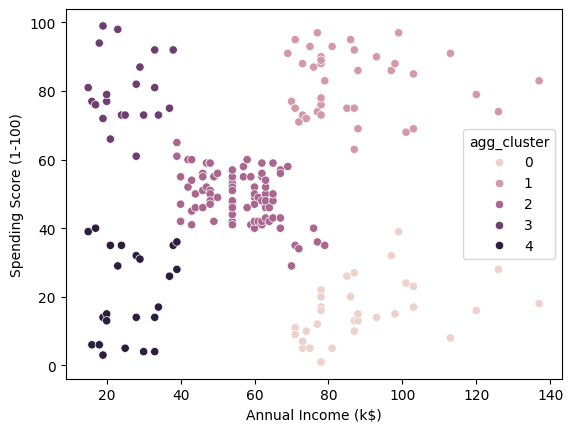

In [ ]:
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)', hue='agg_cluster')

In [ ]:
sil_scores={}

for i in range(2,11):
  agg_hc=AgglomerativeClustering(n_clusters=i,metric='euclidean',linkage='ward')
  sil_h=silhouette_score(X_scaled,agg_hc.fit_predict(X_scaled))
  sil_scores[i]=sil_h

In [ ]:
sil_scores

{2: np.float64(0.3842337621772661),
 3: np.float64(0.4610481446570447),
 4: np.float64(0.4925507715349343),
 5: np.float64(0.5538089226688662),
 6: np.float64(0.5386761871036926),
 7: np.float64(0.5197949293475768),
 8: np.float64(0.4308617778221774),
 9: np.float64(0.43768997758154127),
 10: np.float64(0.4339007174968657)}

In [ ]:
from scipy.cluster.hierarchy import fcluster

In [ ]:
cluster_labels=fcluster(mergings,t=5,criterion='maxclust')
cluster_labels

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 5,
       4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1, 5, 1, 5, 1, 2, 1, 2, 1,
       5, 1, 2, 1, 2, 1, 2, 1, 2, 1, 5, 1, 2, 1, 5, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 5, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

In [ ]:

#DBSCAN
from sklearn.cluster import DBSCAN

In [ ]:
db=DBSCAN(eps=0.25,min_samples=5)
db_cluster=db.fit_predict(X_scaled)
db_cluster

array([-1,  0, -1,  0, -1,  0, -1, -1, -1,  0, -1, -1, -1,  0, -1,  0,  1,
        0,  1, -1,  1,  0, -1,  0, -1, -1,  1, -1,  1, -1, -1,  0, -1, -1,
       -1, -1, -1, -1, -1, -1,  2, -1,  2,  2, -1,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  3,  2,  3,  2,  3,  4,  3,  4,  3,  2,  3,  4,  3,
        4,  3,  4,  3,  4,  3,  2,  3,  4,  3,  2,  3,  4,  3,  4,  3,  4,
        3,  4,  3,  4,  3,  4,  3,  2,  3,  4,  3, -1, -1,  5,  3, -1, -1,
        5, -1,  5,  3,  5,  3,  5, -1,  5,  3, -1,  3,  5,  3, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [ ]:
#FISH

In [ ]:
df=pd.read_csv("/content/fish (1).csv")
df

,Bream,242.0,23.2,25.4,30.0,38.4,13.4
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2
...,...,...,...,...,...,...,...
79,Pike,950.0,48.3,51.7,55.1,16.2,11.2
80,Pike,1250.0,52.0,56.0,59.7,17.9,11.7
81,Pike,1600.0,56.0,60.0,64.0,15.0,9.6
82,Pike,1550.0,56.0,60.0,64.0,15.0,9.6


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Bream   84 non-null     object 
 1   242.0   84 non-null     float64
 2   23.2    84 non-null     float64
 3   25.4    84 non-null     float64
 4   30.0    84 non-null     float64
 5   38.4    84 non-null     float64
 6   13.4    84 non-null     float64
dtypes: float64(6), object(1)
memory usage: 4.7+ KB


In [ ]:
df.describe()

,242.0,23.2,25.4,30.0,38.4,13.4
count,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000
mean,434.017857,27.388095,29.607143,33.157143,27.953571,12.859524
std,382.648669,11.348058,12.249630,13.272086,10.351142,2.129377
min,0.000000,9.300000,9.800000,10.800000,14.500000,8.700000
25%,120.000000,19.325000,20.950000,23.550000,16.875000,10.875000
50%,390.000000,28.450000,30.850000,35.050000,26.900000,13.700000
75%,657.500000,32.725000,36.000000,40.675000,39.225000,14.700000
max,1650.000000,59.000000,63.400000,68.000000,44.500000,16.100000


In [ ]:
df.isnull().sum()

,0
Bream,0
242.0,0
23.2,0
25.4,0
30.0,0
38.4,0
13.4,0


In [ ]:
df['Bream'].value_counts()

,count
Bream,
Bream,33
Roach,20
Pike,17
Smelt,14


In [ ]:
df2=df.rename(columns={'Bream':'Species','242.0':'Weight','23.2':' vlength','25.4':'Dlength',
                              '30.0':'Clength','38.4':'Height','13.4':'Width'})
df2

,Species,Weight,vlength,Dlength,Clength,Height,Width
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2
...,...,...,...,...,...,...,...
79,Pike,950.0,48.3,51.7,55.1,16.2,11.2
80,Pike,1250.0,52.0,56.0,59.7,17.9,11.7
81,Pike,1600.0,56.0,60.0,64.0,15.0,9.6
82,Pike,1550.0,56.0,60.0,64.0,15.0,9.6


In [ ]:
df2['Weight'].value_counts()

,count
Weight,
500.0,5
300.0,3
700.0,3
290.0,2
390.0,2
...,...
770.0,1
1250.0,1
1600.0,1


In [ ]:
df2.drop(['Species'],axis=1,inplace=True)
df2

,Weight,vlength,Dlength,Clength,Height,Width
0,290.0,24.0,26.3,31.2,40.0,13.8
1,340.0,23.9,26.5,31.1,39.8,15.1
2,363.0,26.3,29.0,33.5,38.0,13.3
3,430.0,26.5,29.0,34.0,36.6,15.1
4,450.0,26.8,29.7,34.7,39.2,14.2
...,...,...,...,...,...,...
79,950.0,48.3,51.7,55.1,16.2,11.2
80,1250.0,52.0,56.0,59.7,17.9,11.7
81,1600.0,56.0,60.0,64.0,15.0,9.6
82,1550.0,56.0,60.0,64.0,15.0,9.6


<Axes: >

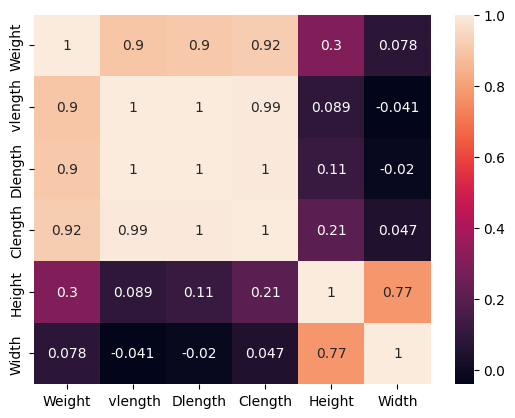

In [ ]:
sns.heatmap(df2.corr(),annot=True)

In [ ]:
df2.corr()

,Weight,vlength,Dlength,Clength,Height,Width
Weight,1.000000,0.897336,0.903897,0.917724,0.297796,0.077788
vlength,0.897336,1.000000,0.999505,0.992544,0.088572,-0.041463
Dlength,0.903897,0.999505,1.000000,0.995397,0.114809,-0.019740
Clength,0.917724,0.992544,0.995397,1.000000,0.205021,0.046769
Height,0.297796,0.088572,0.114809,0.205021,1.000000,0.772772
Width,0.077788,-0.041463,-0.019740,0.046769,0.772772,1.000000


<Axes: xlabel=' vlength', ylabel='Weight'>

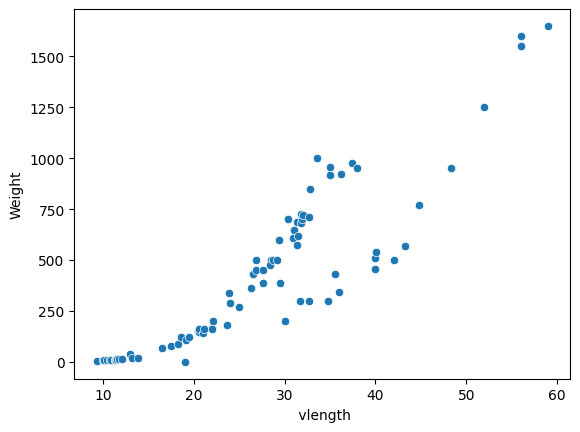

In [ ]:
sns.scatterplot(data=df2,y='Weight',x=' vlength')

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df2)
X_scaled

array([[-0.37863149, -0.30035487, -0.2716005 , -0.14834877,  1.1707675 ,
         0.44432002],
       [-0.24717853, -0.30921988, -0.25517542, -0.15592863,  1.15132991,
         1.05849403],
       [-0.18671016, -0.09645972, -0.04986186,  0.02598811,  0.97639163,
         0.20809925],
       [-0.01056318, -0.0787297 , -0.04986186,  0.06388743,  0.84032853,
         1.05849403],
       [ 0.042018  , -0.05213468,  0.00762593,  0.11694647,  1.09301715,
         0.63329664],
       [ 0.17347097, -0.05213468,  0.00762593,  0.10178675,  1.27767423,
         1.15298234],
       [-0.11572556,  0.01878537,  0.03226356,  0.13968607,  0.80145335,
         0.25534341],
       [ 0.042018  ,  0.01878537,  0.03226356,  0.14726593,  1.16104871,
         0.44432002],
       [ 0.17347097,  0.09857043,  0.08975135,  0.23064443,  1.10273595,
         0.39707587],
       [ 0.10774449,  0.08970542,  0.11438898,  0.23064443,  1.11245474,
         0.58605249],
       [ 0.17347097,  0.11630044,  0.11438898,  0.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
wcss=[]
sil_scores=[]
for k in range(2,11):
  kmeans=KMeans(n_clusters=k,random_state=42, init='k-means++',max_iter=300,n_init=10)
  kmeans.fit_predict(X_scaled)
  labels=kmeans.labels_
  wcss.append(kmeans.inertia_)
  sil_h=silhouette_score(X_scaled,labels)
  sil_scores.append(sil_h)



In [ ]:
wcss

[280.8885702054668,
 152.5179439645251,
 95.64140388334205,
 50.026131940094956,
 37.644057812505125,
 31.312635895196696,
 26.616726837940814,
 22.877937488820372,
 19.869090999980866]

In [ ]:
sil_scores

[np.float64(0.42139204536105773),
 np.float64(0.5208681740121003),
 np.float64(0.5725442214804736),
 np.float64(0.6133697760528423),
 np.float64(0.5306266143418771),
 np.float64(0.5054627995747389),
 np.float64(0.5007401934459985),
 np.float64(0.4480581092940773),
 np.float64(0.44679580208759)]

In [ ]:
for i,k in enumerate(range(2,11)):
  print(f"for k={k}, wcss={wcss[i]:.2f} and sil_score={sil_scores[i]:.2f}")

for k=2, wcss=280.89 and sil_score=0.42
for k=3, wcss=152.52 and sil_score=0.52
for k=4, wcss=95.64 and sil_score=0.57
for k=5, wcss=50.03 and sil_score=0.61
for k=6, wcss=37.64 and sil_score=0.53
for k=7, wcss=31.31 and sil_score=0.51
for k=8, wcss=26.62 and sil_score=0.50
for k=9, wcss=22.88 and sil_score=0.45
for k=10, wcss=19.87 and sil_score=0.45


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

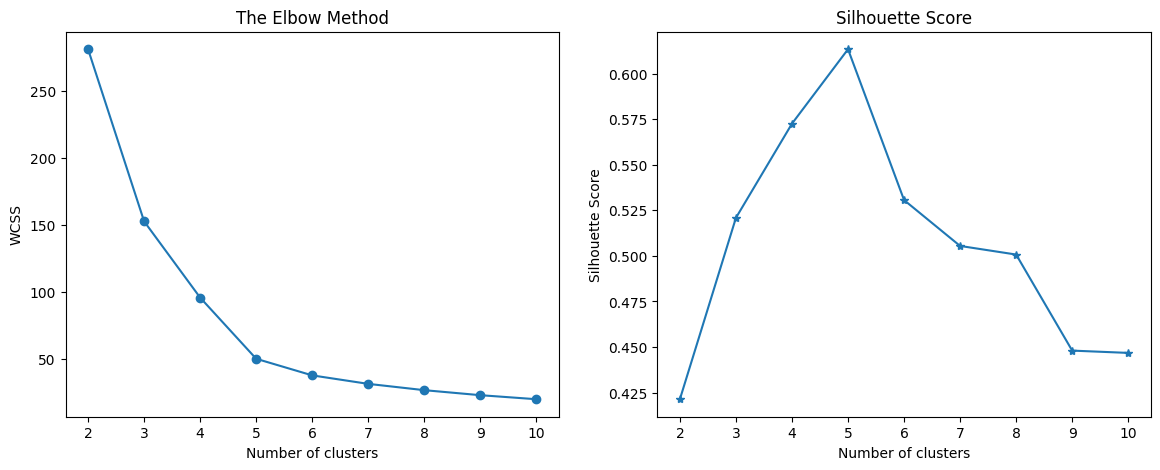

In [ ]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(range(2,11),wcss,marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

plt.subplot(1,2,2)
plt.plot(range(2,11),sil_scores,marker='*')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt

In [ ]:
#optimal num:5

In [ ]:
kmeans=KMeans(n_clusters=5,random_state=42, init='k-means++',max_iter=300,n_init=10)
kmeans.fit_predict(X_scaled)
cluster_labels=kmeans.predict(X_scaled)
cluster_labels


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1,
       3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4], dtype=int32)

In [ ]:
df['Kmeans_cluster']=cluster_labels
df.head()

,Bream,242.0,23.2,25.4,30.0,38.4,13.4,Kmeans_cluster
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8,0
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1,0
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3,0
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1,0
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2,0


In [ ]:
df['Kmeans_cluster'].value_counts()

,count
Kmeans_cluster,
0,34
1,20
3,13
2,12
4,5


<Axes: xlabel=' vlength', ylabel='Weight'>

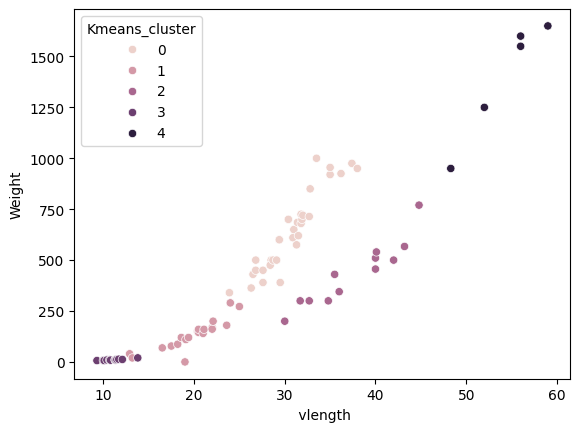

In [ ]:
df2['Kmeans_cluster'] = cluster_labels
sns.scatterplot(data=df2, y='Weight', x=' vlength', hue='Kmeans_cluster')

In [ ]:
new_fish=np.array([[20,200,20,30,20,20]])
scaled= scaler.transform(new_fish)
cluster=kmeans.predict(scaled)
cluster

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4], dtype=int32)

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

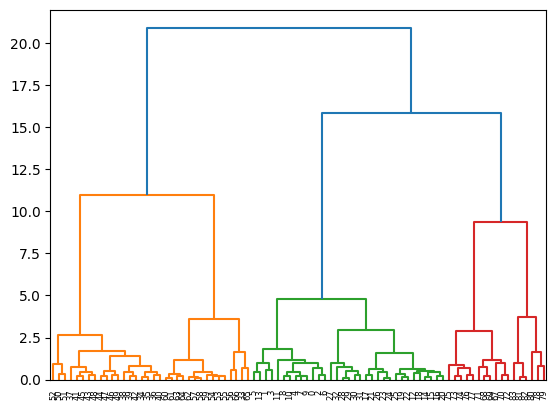

In [ ]:
mergings=linkage(X_scaled,method='ward')
dendrogram(mergings)
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

In [ ]:
agg_hc=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
agg_cluster=agg_hc.fit_predict(X_scaled)
agg_cluster

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2])

In [ ]:
df2['agg_cluster']=agg_cluster
df2.head()

,Weight,vlength,Dlength,Clength,Height,Width,Kmeans_cluster,agg_cluster
0,290.0,24.0,26.3,31.2,40.0,13.8,0,0
1,340.0,23.9,26.5,31.1,39.8,15.1,0,0
2,363.0,26.3,29.0,33.5,38.0,13.3,0,0
3,430.0,26.5,29.0,34.0,36.6,15.1,0,0
4,450.0,26.8,29.7,34.7,39.2,14.2,0,0


In [ ]:
df2

,Weight,vlength,Dlength,Clength,Height,Width,Kmeans_cluster,agg_cluster
0,290.0,24.0,26.3,31.2,40.0,13.8,0,0
1,340.0,23.9,26.5,31.1,39.8,15.1,0,0
2,363.0,26.3,29.0,33.5,38.0,13.3,0,0
3,430.0,26.5,29.0,34.0,36.6,15.1,0,0
4,450.0,26.8,29.7,34.7,39.2,14.2,0,0
...,...,...,...,...,...,...,...,...
79,950.0,48.3,51.7,55.1,16.2,11.2,4,2
80,1250.0,52.0,56.0,59.7,17.9,11.7,4,2
81,1600.0,56.0,60.0,64.0,15.0,9.6,4,2
82,1550.0,56.0,60.0,64.0,15.0,9.6,4,2


In [ ]:
agg_cluster

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2])

<Axes: xlabel=' vlength', ylabel='Weight'>

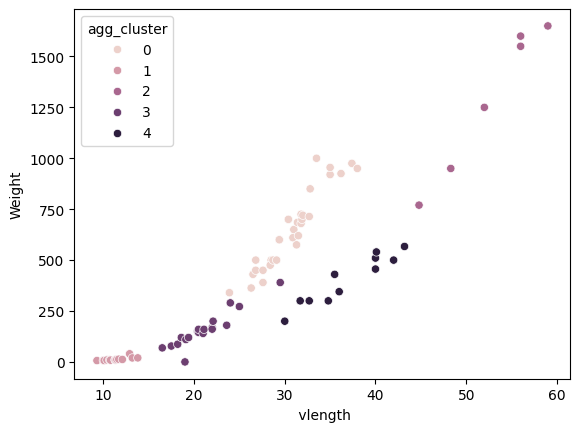

In [ ]:
sns.scatterplot(data=df2, y='Weight', x=' vlength', hue='agg_cluster')

In [ ]:
sil_scores={}

for i in range(2,11):
  agg_hc=AgglomerativeClustering(n_clusters=i,metric='euclidean',linkage='ward')
  sil_h=silhouette_score(X_scaled,agg_hc.fit_predict(X_scaled))
  sil_scores[i]=sil_h

In [ ]:
sil_scores

{2: np.float64(0.4145080144933428),
 3: np.float64(0.511730107492879),
 4: np.float64(0.5465520404406123),
 5: np.float64(0.580437586628707),
 6: np.float64(0.49769191018862036),
 7: np.float64(0.490192410339021),
 8: np.float64(0.4665934938924753),
 9: np.float64(0.4644330100024386),
 10: np.float64(0.4541055703695885)}

In [ ]:
from scipy.cluster.hierarchy import fcluster

In [ ]:
cluster_labels=fcluster(mergings,t=5,criterion='maxclust')
cluster_labels

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5], dtype=int32)

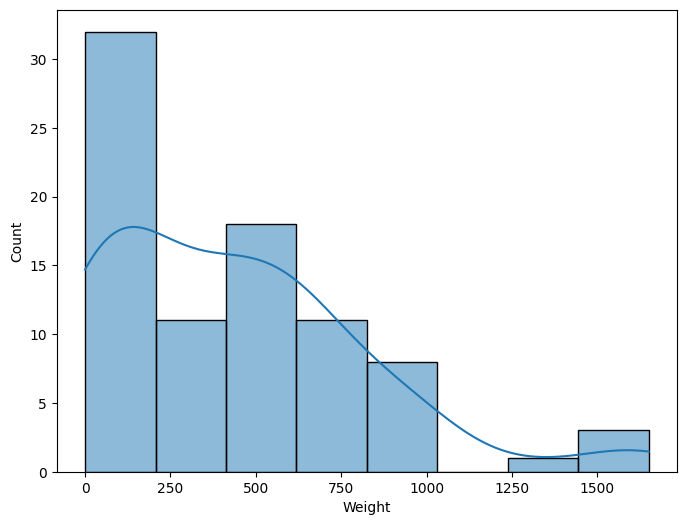

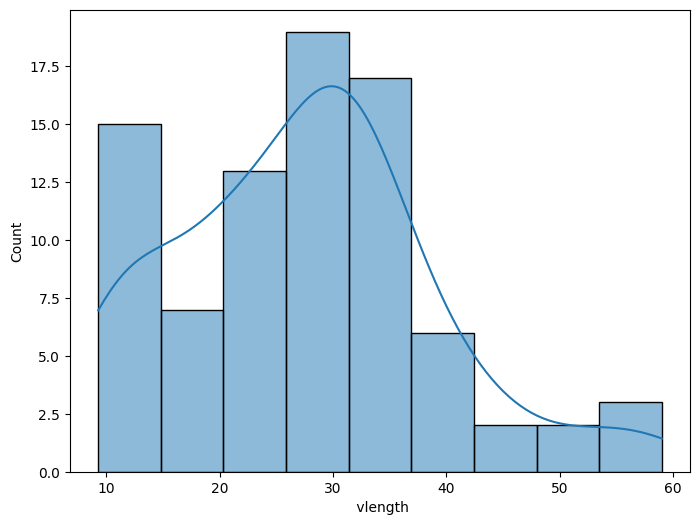

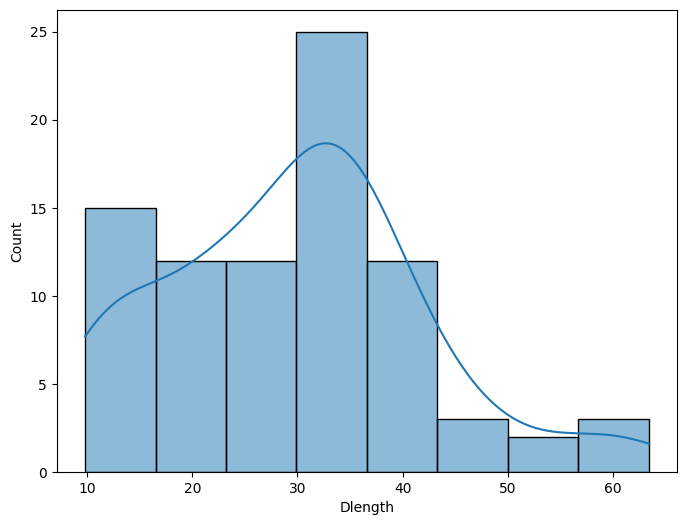

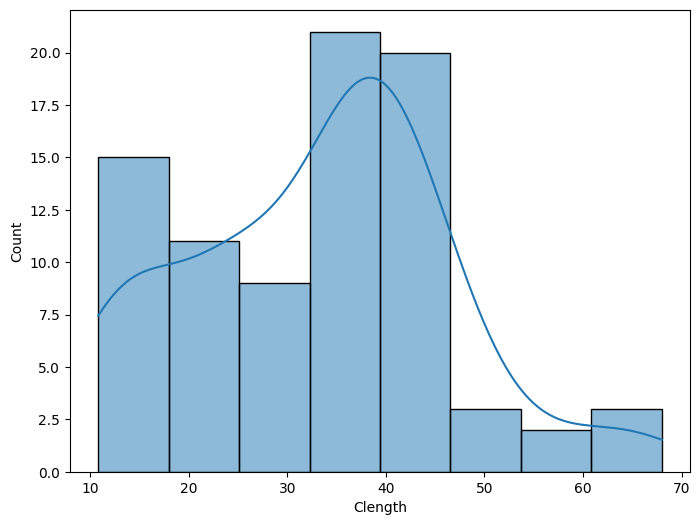

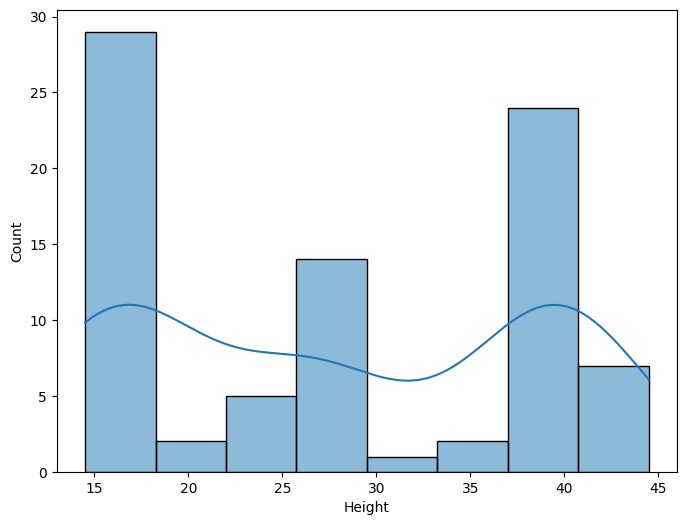

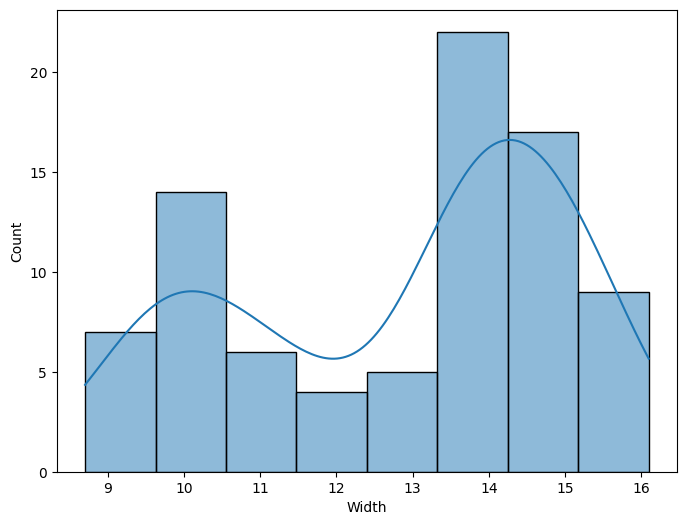

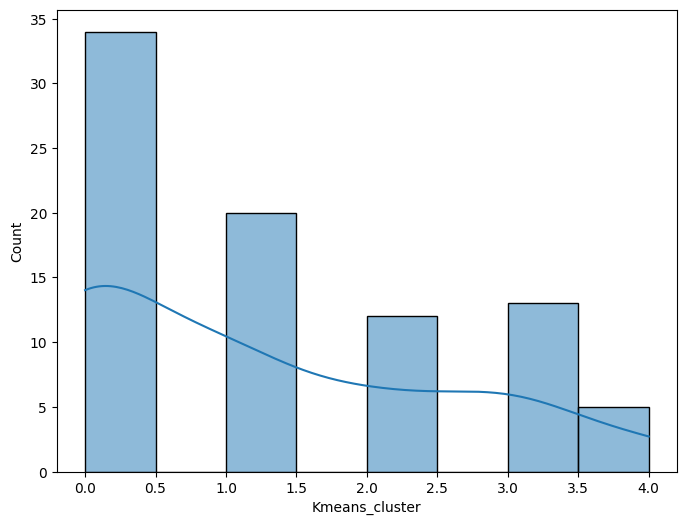

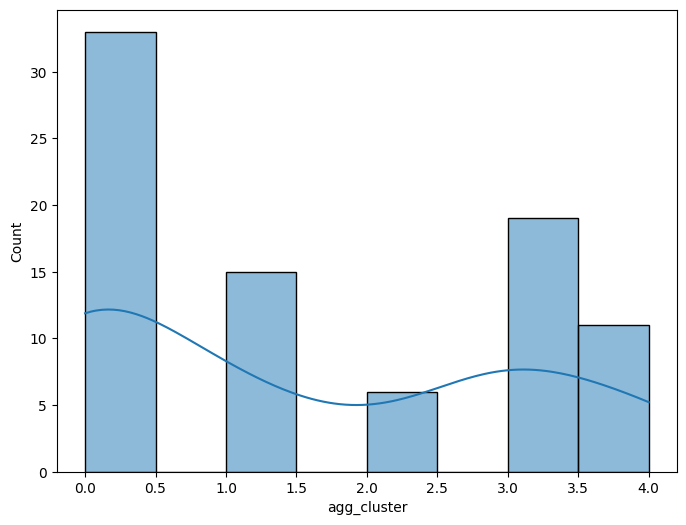

In [ ]:
numerical_cols=df2.select_dtypes(include=np.number).columns
for col in numerical_cols:
  plt.figure(figsize=(8,6))
  sns.histplot(df2[col],kde=True)
  plt.show()




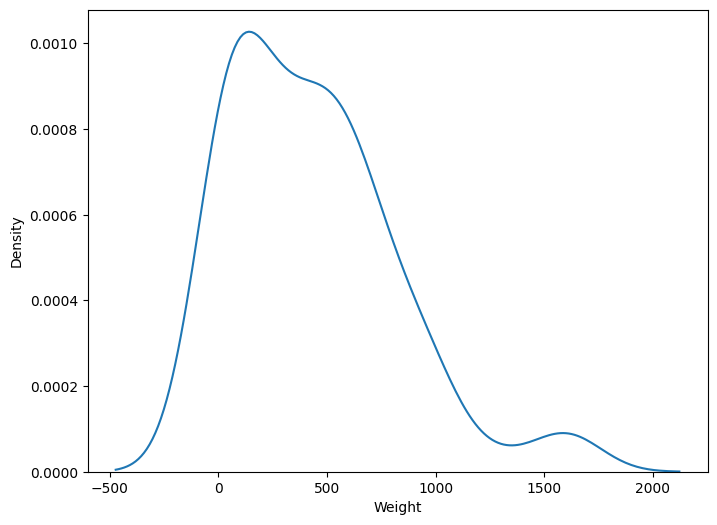

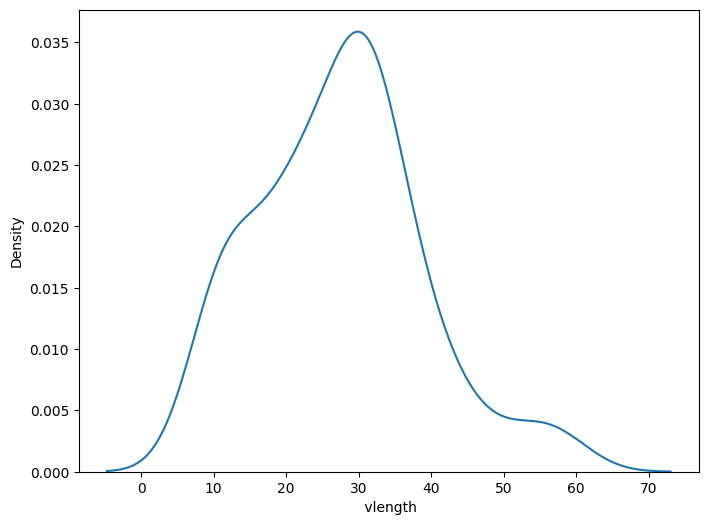

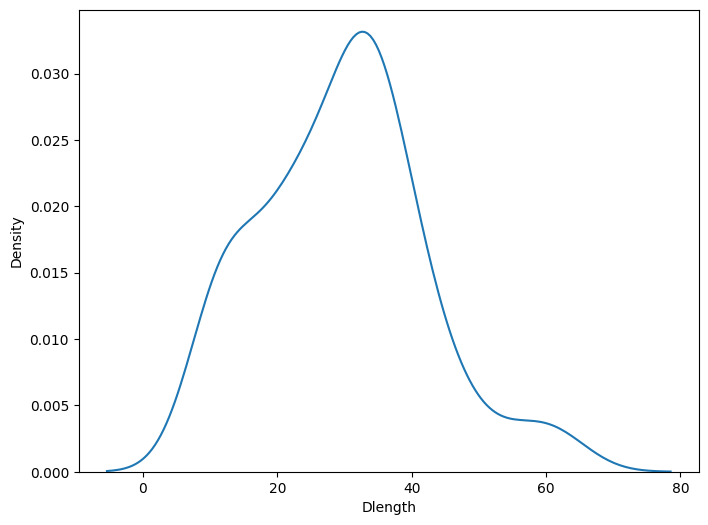

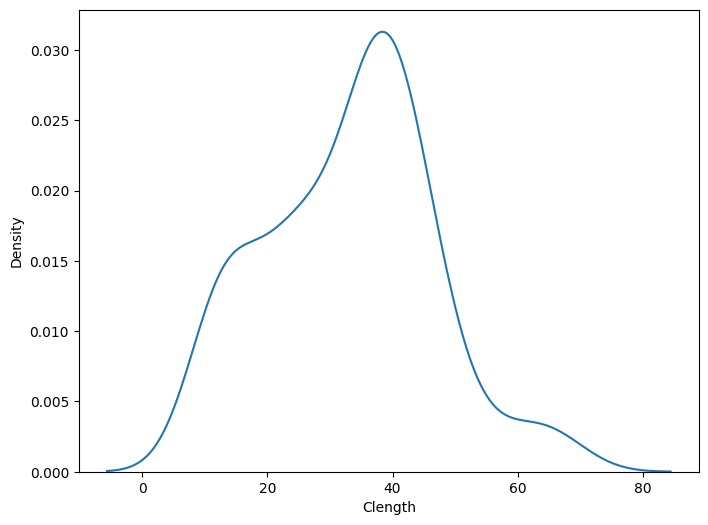

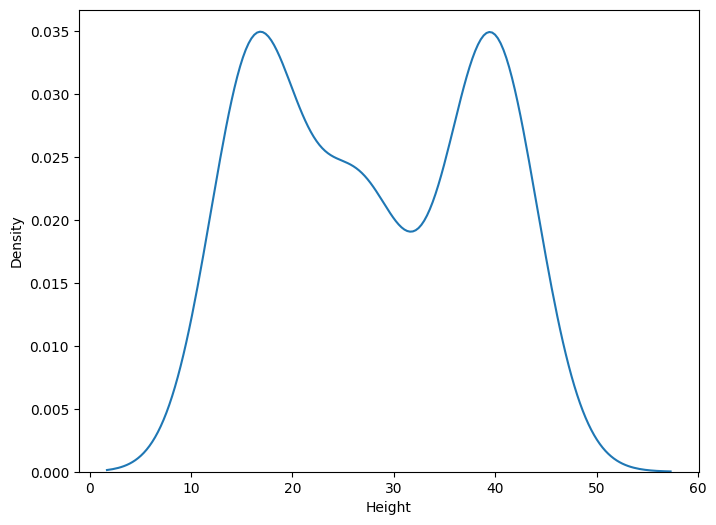

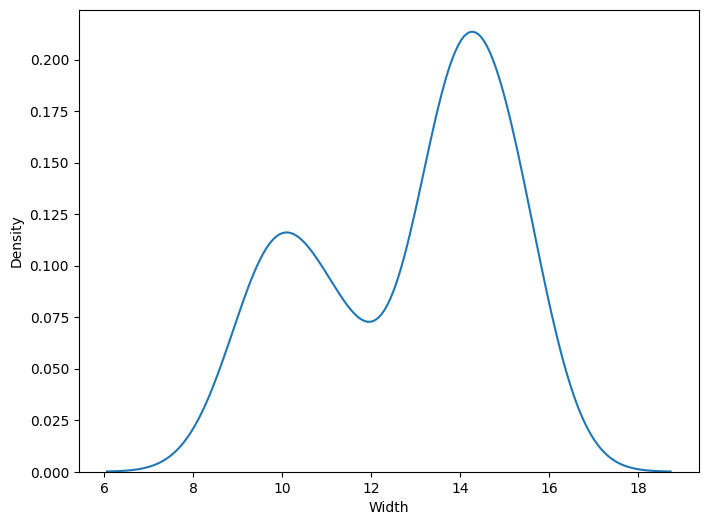

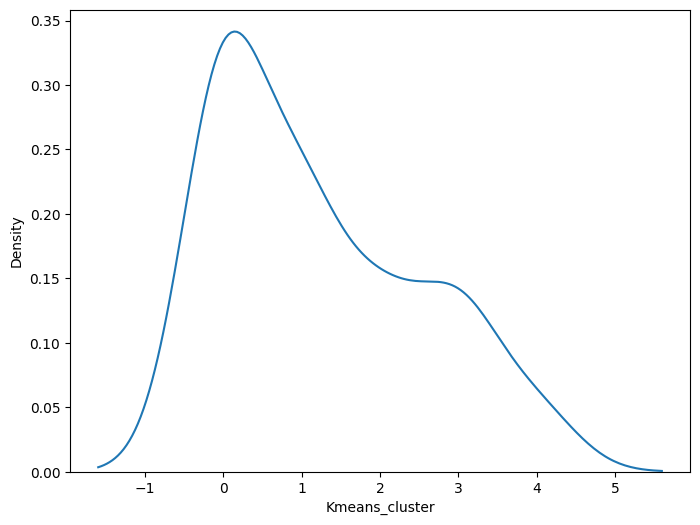

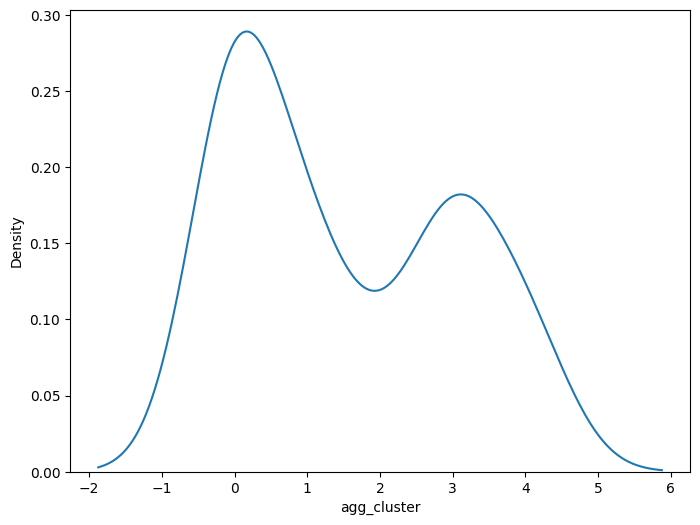

In [ ]:
#dbscan identifies outliers
numerical_cols=df2.select_dtypes(include=np.number).columns
for col in numerical_cols:
  plt.figure(figsize=(8,6))
  sns.kdeplot(df2[col])
  plt.show()


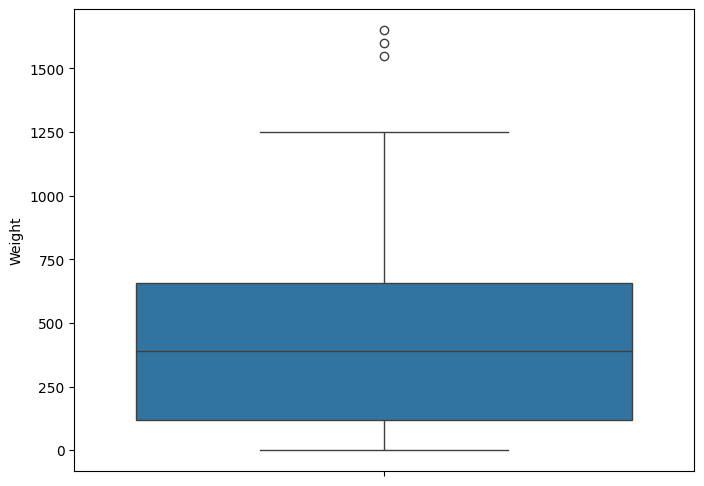

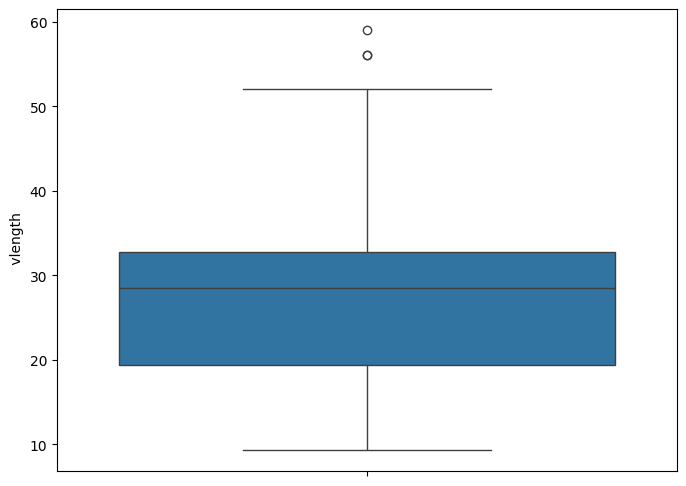

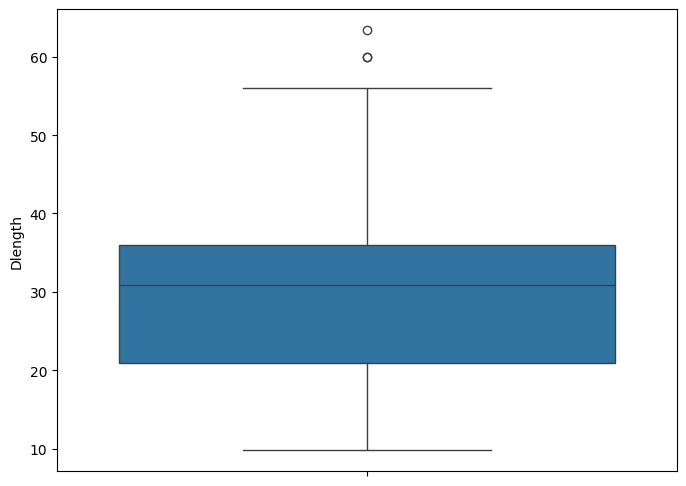

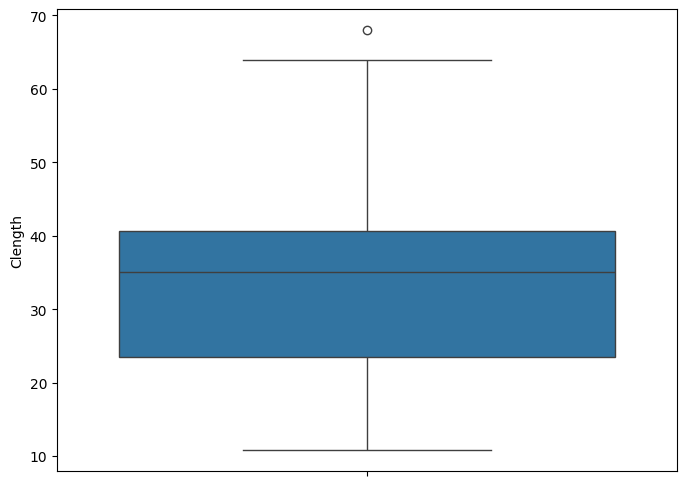

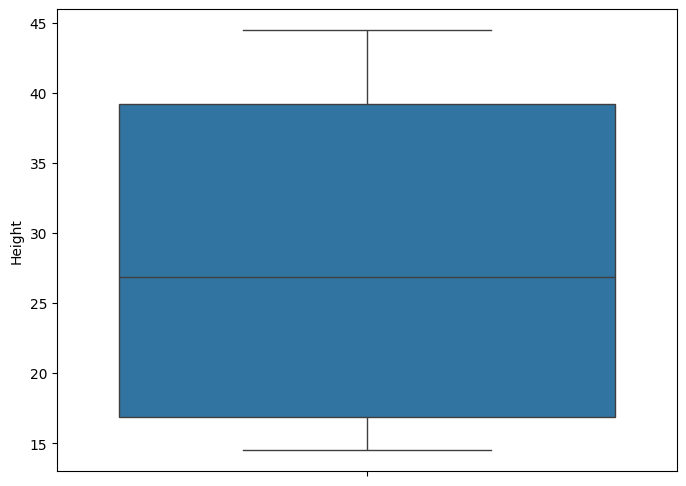

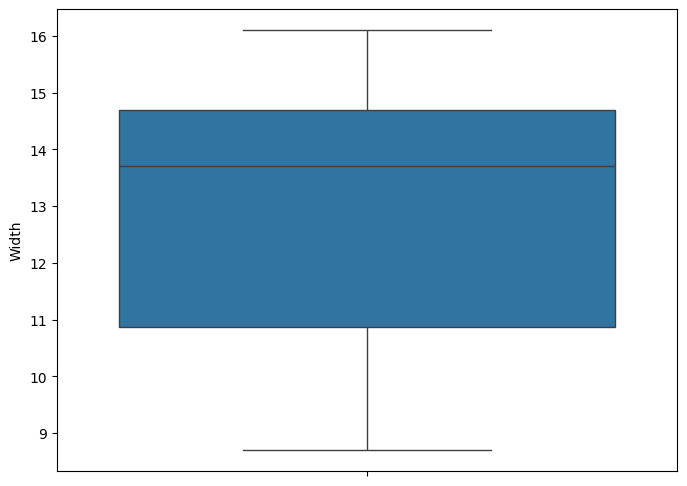

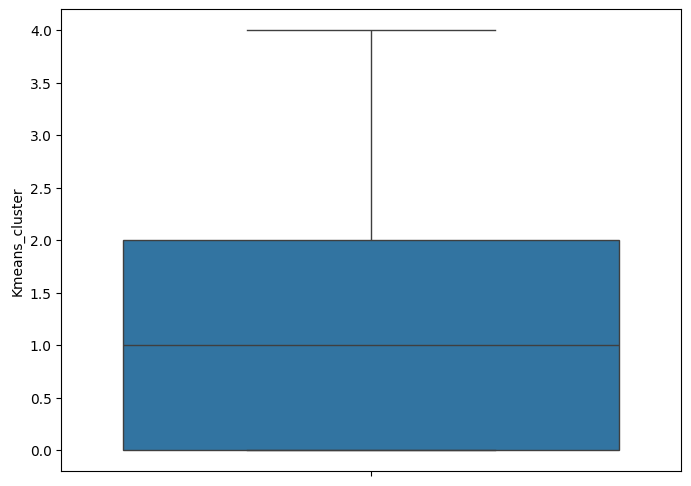

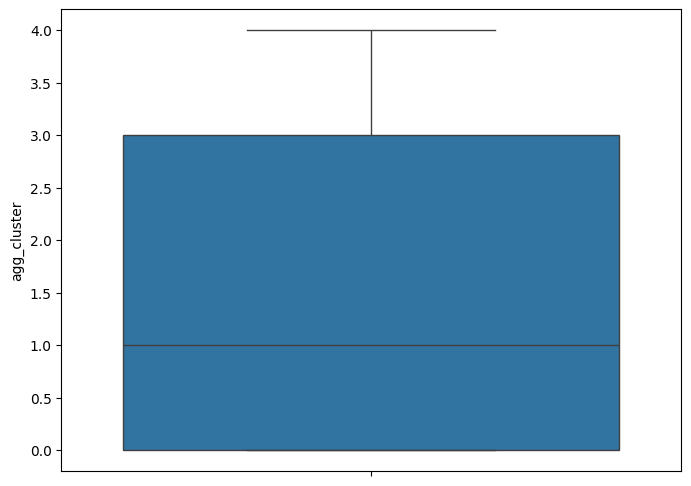

In [ ]:
numerical_cols=df2.select_dtypes(include=np.number).columns
for col in numerical_cols:
  plt.figure(figsize=(8,6))
  sns.boxplot(df2[col])


In [ ]:
from scipy.stats import skew
for col in numerical_cols:
  print(f"{col}: {skew(df2[col])}")

Weight: 1.07396759541638
 vlength: 0.4770076953373895
Dlength: 0.410608216695312
Clength: 0.1595542648758241
Height: 0.054163234011628904
Width: -0.48536327950525565
Kmeans_cluster: 0.6839865574419176
agg_cluster: 0.38158323908958275


In [ ]:
df2.skew()

,0
Weight,1.093594
vlength,0.485725
Dlength,0.418112
Clength,0.162470
Height,0.055153
Width,-0.494233
Kmeans_cluster,0.696486
agg_cluster,0.388556


In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)


In [ ]:
y_dbscan

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  0,  0,  0,
       -1, -1,  0, -1, -1,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1,  1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [ ]:
df['Cluster'] = y_dbscan

In [ ]:
df['Cluster']

,Cluster
0,-1
1,-1
2,-1
3,-1
4,-1
...,...
79,-1
80,-1
81,-1
82,-1


In [ ]:
df['Cluster'].value_counts()

,count
Cluster,
-1,71
1,8
0,5


In [ ]:
print(df['Cluster'].value_counts())

Cluster
-1    71
 1     8
 0     5
Name: count, dtype: int64


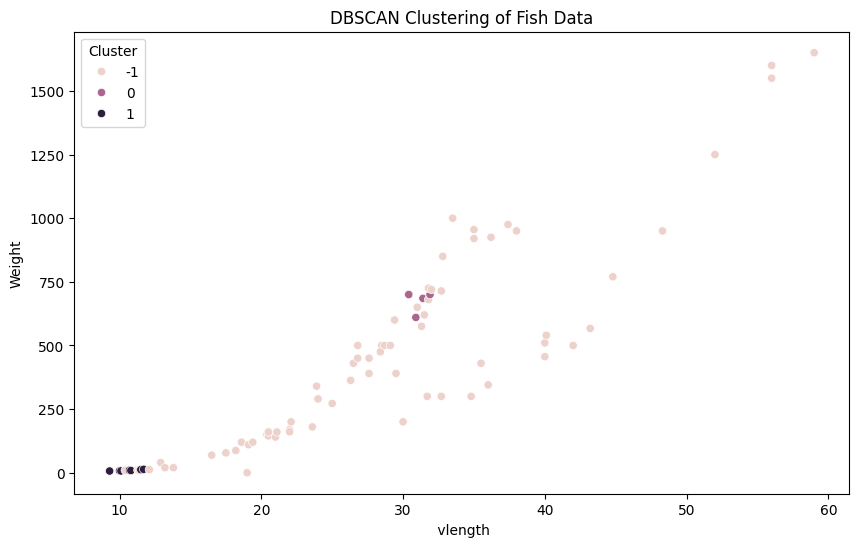

In [ ]:
df2['Cluster'] = y_dbscan
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df2, y='Weight', x=' vlength', hue='Cluster')
plt.title('DBSCAN Clustering of Fish Data')
plt.show()